# 19 — Bonsai (Ternary 27B) behind the ewm-sm side-car: the lattice as context manager

PrismML's **Bonsai 2 27B** is a ternary-weight reasoning model (1.75 bpw,
5.9–7.8 GB) that runs on this machine's RTX 3060 through their llama.cpp
fork, with 262K-token context, hybrid attention and RAM-tiered KV cache.
Its context management is token-level: prefix caches, KV checkpoints, 4-bit
KV.

This notebook shows where ewm-sm fits: **above the token level, as a
content-addressed context manager.** Bonsai's answers are tokenized into
`tid{n}` streams, ingested into the HLLSet lattice, and the materialized
memory (restored order, deduplicated, capped) becomes the *only* context
Bonsai sees on the next turn. The lattice decides what Bonsai remembers;
Bonsai's own KV cache then handles that context efficiently.

Two streams are captured per answer — the final **answer** and the
**reasoning** trace — as two perceptrons of the union `S(t)`.

In [1]:
import os, sys, json

import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import (
    BonsaiAdapter,
    EwmScene,
    memory_tokens,
    run_open_loop_from_streams,
    write_frames,
)

WORK = "/home/alexmy/.cache/ewm-bonsai"
os.makedirs(WORK, exist_ok=True)

ewm = EwmScene()
bonsai = BonsaiAdapter(base_url="http://127.0.0.1:8081")
print("ewm-scene:", ewm.bin)
print("bonsai server health:", bonsai.health())

ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
bonsai server health: True


In [2]:
QUERIES = [
    "What is the capital of France? Answer in one short sentence.",
    "Explain gravity in one sentence.",
    "Write a haiku about rain.",
    "What is the speed of light? Answer in one short sentence.",
    "Who wrote Romeo and Juliet? Answer in one short sentence.",
    "Name three planets in our solar system.",
]

## §1 — Open loop: capture Bonsai's answer + reasoning streams

In [3]:
streams = {"bonsai_answer": [], "bonsai_reasoning": []}
for q in QUERIES:
    answer, reasoning = bonsai.chat(q, max_tokens=128, temperature=0.0)
    streams["bonsai_answer"].append([f"tid{i}" for i in bonsai.tokenize(answer)])
    streams["bonsai_reasoning"].append([f"tid{i}" for i in bonsai.tokenize(reasoning)])
    print(f"q: {q[:48]:48s} -> answer={answer[:40]!r}  "
          f"tids(ans)={len(streams['bonsai_answer'][-1])}, tids(reas)={len(streams['bonsai_reasoning'][-1])}")

open_result = run_open_loop_from_streams(ewm, streams, WORK)
print()
print("IICA (union == pyramid union):", open_result.same_union)
print("BSS trajectory:", open_result.M_ol.shape, "| frontends:", open_result.names)

q: What is the capital of France? Answer in one sho -> answer='The capital of France is Paris.'  tids(ans)=7, tids(reas)=30
q: Explain gravity in one sentence.                 -> answer='Gravity is the attractive force between '  tids(ans)=24, tids(reas)=24
q: Write a haiku about rain.                        -> answer=''  tids(ans)=0, tids(reas)=128
q: What is the speed of light? Answer in one short  -> answer='The speed of light in a vacuum is exactl'  tids(ans)=25, tids(reas)=51
q: Who wrote Romeo and Juliet? Answer in one short  -> answer='William Shakespeare wrote Romeo and Juli'  tids(ans)=7, tids(reas)=15
q: Name three planets in our solar system.          -> answer='Mercury, Earth, and Jupiter.'  tids(ans)=8, tids(reas)=19

IICA (union == pyramid union): True
BSS trajectory: (6, 2) | frontends: ['bonsai_answer', 'bonsai_reasoning']


## §2 — Closed loop: the lattice decides what Bonsai remembers

Each turn: the materialized memory (restored order) is detokenized into
text, prefixed to the query, and sent to Bonsai. The answer is tokenized
and ingested, and the loop repeats. Bonsai never sees the raw chat history —
only the lattice-materialized state.

In [4]:
union_path = f"{WORK}/bonsai_loop_union.jsonl"
open(union_path, "w").close()

mem_tids: list[str] = []
M_rows = []
mem_lens = []
for t, q in enumerate(QUERIES):
    mem_text = bonsai.detokenize([int(x[3:]) for x in mem_tids]) if mem_tids else ""
    prompt = f"Context memory (restored by the state machine):\n{mem_text}\n\nQuery: {q}"
    answer, _ = bonsai.chat(prompt, max_tokens=128, temperature=0.0)
    tids = [f"tid{i}" for i in bonsai.tokenize(answer)]

    with open(union_path, "a") as fh:
        fh.write(json.dumps({"id": t + 1, "tokens": tids}) + "\n")

    proj = ewm.project(union_path, open_result.frame_path)
    m_t = np.array(proj["frames"][-1]["bss"])
    M_rows.append(m_t)

    mat = ewm.materialize(union_path)
    mem_tids = memory_tokens(mat["frames"][-1]["ordered"])
    mem_lens.append(len(mem_tids))
    mem_preview = bonsai.detokenize([int(x[3:]) for x in mem_tids[:12]])
    print(f"t={t} q={q[:40]:40s} ans={answer[:36]!r}  "
          f"bss={np.round(m_t, 3)}  mem={len(mem_tids)} tids  preview={mem_preview[:60]!r}")

M_loop = np.array(M_rows)
print()
print("closed-loop BSS trajectory:", M_loop.shape)

t=0 q=What is the capital of France? Answer in ans='Paris is the capital of France.'  bss=[0.116 0.064]  mem=7 tids  preview='Paris is the capital of France.'
t=1 q=Explain gravity in one sentence.         ans='Gravity is the attractive force betw'  bss=[0.361 0.103]  mem=24 tids  preview=' the attractive force between objects with mass that pulls t'
t=2 q=Write a haiku about rain.                ans=''  bss=[0. 0.]  mem=0 tids  preview=''
t=3 q=What is the speed of light? Answer in on ans='The speed of light in a vacuum is ab'  bss=[0.381 0.178]  mem=24 tids  preview='The speed of light in a vacuum is about 29'
t=4 q=Who wrote Romeo and Juliet? Answer in on ans='William Shakespeare wrote *Romeo and'  bss=[0.097 0.004]  mem=10 tids  preview='William Shakespeare wrote *Romeo and Juliet*.'
t=5 q=Name three planets in our solar system.  ans='Mercury, Venus, and Earth.'  bss=[0.116 0.021]  mem=8 tids  preview='Mercury, Venus, and Earth.'

closed-loop BSS trajectory: (6, 2)


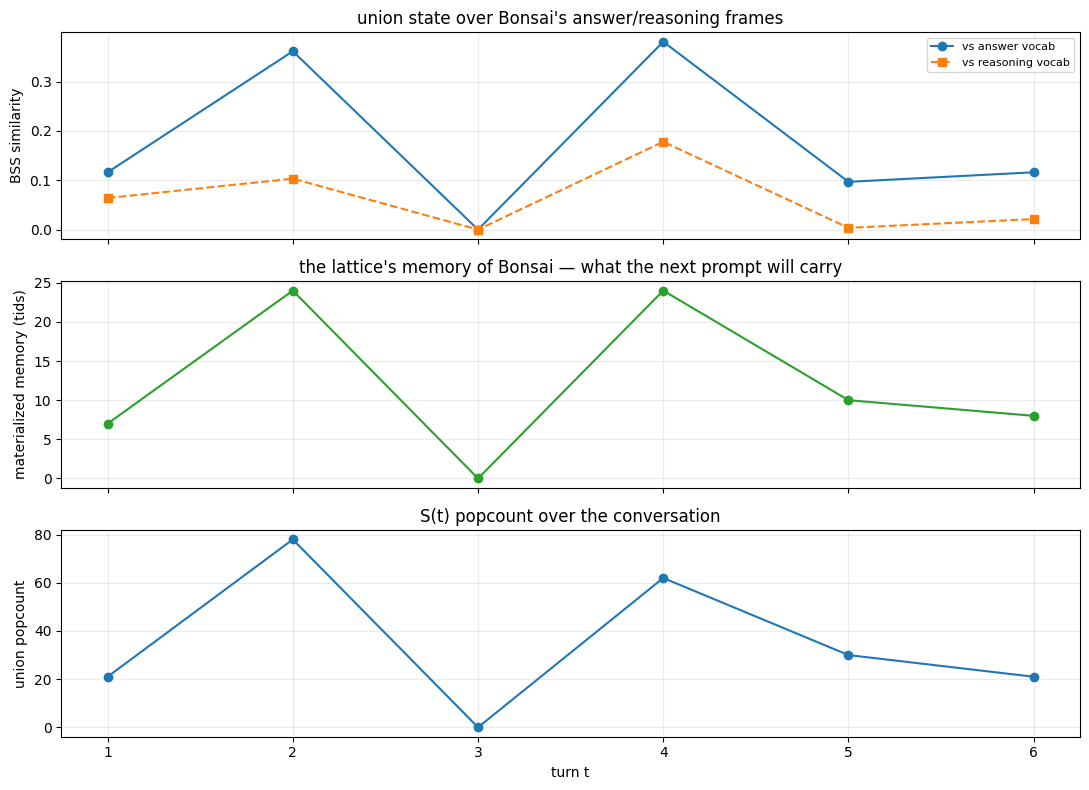

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

t_axis = np.arange(1, len(mem_lens) + 1)
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(t_axis, M_loop[:, 0], "o-", label="vs answer vocab")
axes[0].plot(t_axis, M_loop[:, 1], "s--", label="vs reasoning vocab")
axes[0].set_ylabel("BSS similarity")
axes[0].set_title("union state over Bonsai's answer/reasoning frames")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot(t_axis, mem_lens, "o-", color="tab:green")
axes[1].set_ylabel("materialized memory (tids)")
axes[1].set_title("the lattice's memory of Bonsai — what the next prompt will carry")
axes[1].grid(alpha=0.25)

uni = ewm.ingest(union_path)
pops = [f["pop"] for f in uni["frames"]]
axes[2].plot(t_axis, pops, "o-", color="tab:blue")
axes[2].set_ylabel("union popcount")
axes[2].set_xlabel("turn t")
axes[2].set_title("S(t) popcount over the conversation")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/bonsai_sidecar.png", dpi=110)
plt.show()

## Summary

- **Bonsai 2 27B runs on the RTX 3060 as promised** (5.7 GB on GPU, ~8
  tokens/s) through the PrismML llama.cpp fork.
- The ewm-sm side-car sits **above Bonsai's token-level context**: answers
  and reasoning traces are tid streams, the union `S(t)` accumulates them,
  and the materialized restored-order memory becomes the next prompt's
  context. Bonsai never sees raw chat history — it sees the lattice's
  memory of the conversation.
- This is complementary to Bonsai's own mechanisms (prompt cache, KV
  checkpoints, 4-bit KV): those make a given context cheap to evaluate;
  ewm-sm decides *what that context is*.

Next: replace the detokenized memory prefix with a Bonsai-specific
compressed context (e.g., only the D/R/N-surprising tids), and route
Bonsai + the three small LLMs together under one Laya/Jev router.